# Аналитический отчёт: matplotlib + seaborn

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

import style

sns.set_theme(
    style="whitegrid", 
    context="notebook", 
    palette=style.CATEGORY_PALETTE
)
style.apply_default_style()

REPORT_DIR = Path("reports")
REPORT_DIR.mkdir(exist_ok=True)

df = pd.read_pickle("data/sales_clean.pkl")

# Таблица на уровне заказа: многие вопросы задаются про заказ, а не про строку заказа
orders = df.groupby("ORDERNUMBER").agg(
     ORDERDATE=("ORDERDATE", "first"),
     CUSTOMERNAME=("CUSTOMERNAME", "first"),
     STATUS=("STATUS", "first"),
     STATUS_GROUP=("STATUS_GROUP", "first"),
     SALES_EST=("SALES_EST", "sum"),
     MAX_QTY=("QUANTITYORDERED", "max")
).reset_index()

PERIOD = f"{df['ORDERDATE'].min():%d.%m.%Y}–{df['ORDERDATE'].max():%d.%m.%Y}"
SOURCE = (
     f"Источник: check.csv, {PERIOD}; {len(df):,} строк, {len(orders)} заказов. "
     "Выручка = количество × цена (нижняя оценка: цена обрезана на 100)."
)
print(SOURCE)

Источник: check.csv, 06.01.2003–31.05.2005; 2,823 строк, 307 заказов. Выручка = количество × цена (нижняя оценка: цена обрезана на 100).


## Функции оформления

Одинаковое оформление повторяется на каждом графике. Выносим его в функции:
так графики выглядят единообразно.

In [2]:
def money_fmt(x, pos=None):
    """12 345 678 -> '12.3 млн', 45 000 -> '45 тыс'."""
    if abs(x) >= 1e6:
        return f"{x / 1e6:.1f} млн"
    if abs(x) >= 1e3:
        return f"{x / 1e3:.0f} тыс"
    return f"{x:.0f}"


def set_money_axis(ax, axis="y"):
    target = ax.yaxis if axis == "y" else ax.xaxis
    target.set_major_formatter(mticker.FuncFormatter(money_fmt))


def add_source(fig, text=SOURCE):
    """Подпись с источником, периодом и n — внизу фигуры (чек-лист честного графика)."""
    fig.text(0.01, -0.01, text, fontsize=8, color=style.GRAY, ha="left", va="top")


def plot_barh(ax, s, title="", xlabel="", highlight=(), value_fmt=money_fmt):
    """Горизонтальные столбики, отсортированные по значению; highlight — категории для выделения цветом."""
    s = s.sort_values()
    colors = [style.GREEN if name in highlight else style.BLUE for name in s.index]
    ax.barh(s.index.astype(str), s.values, color=colors)
    for y, v in enumerate(s.values):
        ax.text(v, y, " " + value_fmt(v), va="center", fontsize=9)
    ax.set_title(title, loc="left")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.margins(x=0.18)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
    ax.grid(axis="y", visible=False)
    return ax

# Часть 1. Разведка

Здесь графики «для себя»: минимум оформления, максимум скорости. Задача — **заметить**, что стоит проверить.
Каждое наблюдение записываем одной строкой — это будущие находки отчёта.

In [3]:
df['PRICE_STATUS'] = df['PRICE_CAPPED'].map({False: 'normal', True: 'capped_unknown'})
df.loc[df['PRICE_CAP_CONFIRMED'], 'PRICE_STATUS'] = 'capped_confirmed'

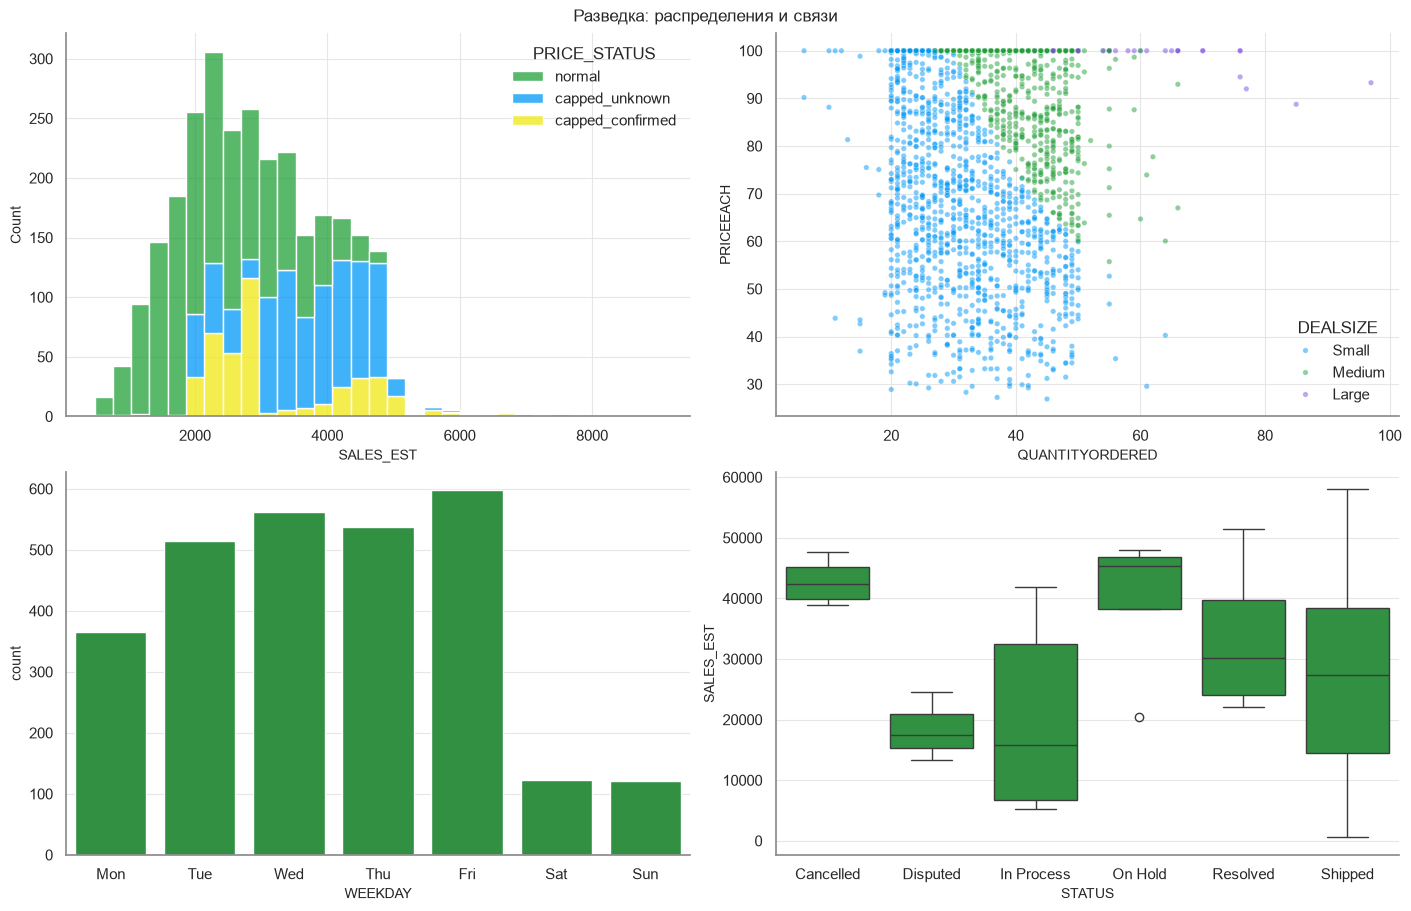

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), layout="constrained")

sns.histplot(
    data=df, x="SALES_EST", hue="PRICE_STATUS", 
    multiple="stack", bins=31,
    palette={
        'normal': style.GREEN, 'capped_unknown': style.BLUE, 
        'capped_confirmed': style.CATEGORY_PALETTE[2]
    }, 
    ax=axes[0, 0]
)
sns.scatterplot(
    data=df, x="QUANTITYORDERED", y="PRICEEACH", hue="DEALSIZE", alpha=0.5, s=15,
    palette=[style.BLUE, style.GREEN, style.CATEGORY_PALETTE[5]], ax=axes[0, 1]
)
sns.countplot(data=df, x="WEEKDAY", ax=axes[1, 0])
sns.boxplot(data=orders, x="STATUS", y="SALES_EST", ax=axes[1, 1])

fig.suptitle("Разведка: распределения и связи")
plt.show()

- (a) у строк с обрезанной ценой выручка в среднем выше — дорогие товары как раз те, где цена обрезана;
- (c) в выходные строк заказов в 4–5 раз меньше, чем в будни, — это скорее всего B2B (оптовые покупатели, а не розница);
- (d) заказы `Cancelled` и `On Hold` выглядят крупнее `Shipped`, а `Disputed` и `In Process` — мельче. **Надо проверить.**

Теперь посмотрим на время: тепловая карта «год × месяц» — быстрый способ увидеть сезонность.

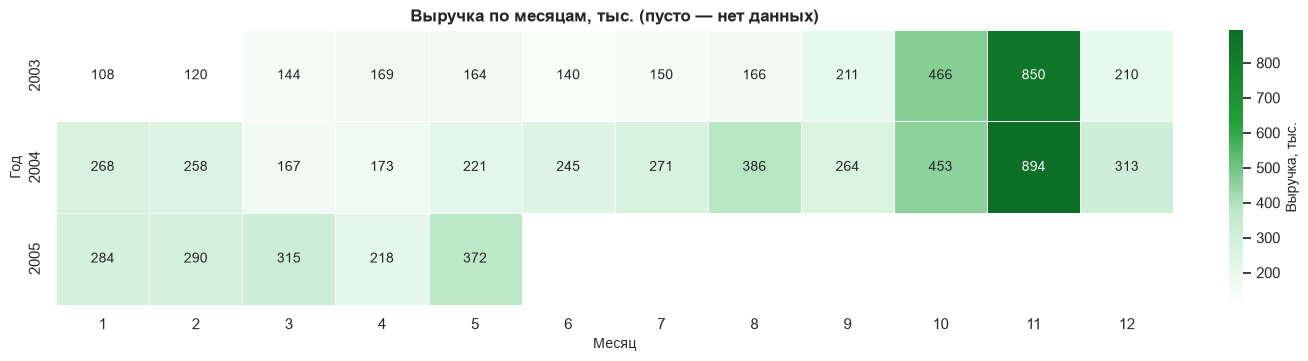

In [10]:
heat = df.pivot_table(index="YEAR_ID", columns="MONTH_ID", values="SALES_EST", aggfunc="sum") / 1e3

fig, ax = plt.subplots(figsize=(13, 3.5), layout="constrained")
sns.heatmap(
    heat, annot=True, fmt=".0f", 
    cmap=style.SEQUENTIAL_CMAP, linewidths=0.5,
    cbar_kws={"label": "Выручка, тыс."}, ax=ax
)
ax.grid(False)
ax.set_title("Выручка по месяцам, тыс. (пусто — нет данных)")
ax.set_xlabel("Месяц")
ax.set_ylabel("Год")
plt.show()

**Что заметили:**

- ноябрь — самый тёмный месяц и в 2003, и в 2004 году, октябрь тоже высокий → **сезонность**;
- 2005 год неполный (январь–май) — **нельзя сравнивать годовые суммы**, только одинаковые месяцы;
- январь–май 2005 темнее, чем в 2004 → возможно, **рост**.

---
# Часть 2. Аналитический отчёт

## Какие факторы определяют продажи компании?

**Период:** январь 2003 — май 2005· 
**Объект:** оптовые продажи коллекционных масштабных моделей клиентам в 19 странах.

### Главное

1. **Сезонность:** ноябрь — пик каждого года; IV квартал даёт **42–53%** годовой выручки.
2. **Рост:** январь–май 2005 на **+36%** выше, чем январь–май 2004. Растёт **число заказов**, а средний заказ не меняется.
3. **Ассортимент:** Classic Cars — **36%** выручки; при этом у 60% его строк цена обрезана, так что реальная доля ещё выше.
4. **Клиенты:** два клиента дают **16%** выручки — заметная зависимость от ключевых покупателей.
5. **Операции:** отменённые и приостановленные (`On Hold`) заказы **крупнее** обычных: медиана ~42–45 тыс. против ~27 тыс. у `Shipped`.

### Находка 1. Сезонность: пик в ноябре

Заголовок графика — **вывод с числом**, и числа в нём считаются из данных, а не пишутся вручную: если данные обновятся, заголовок останется честным.

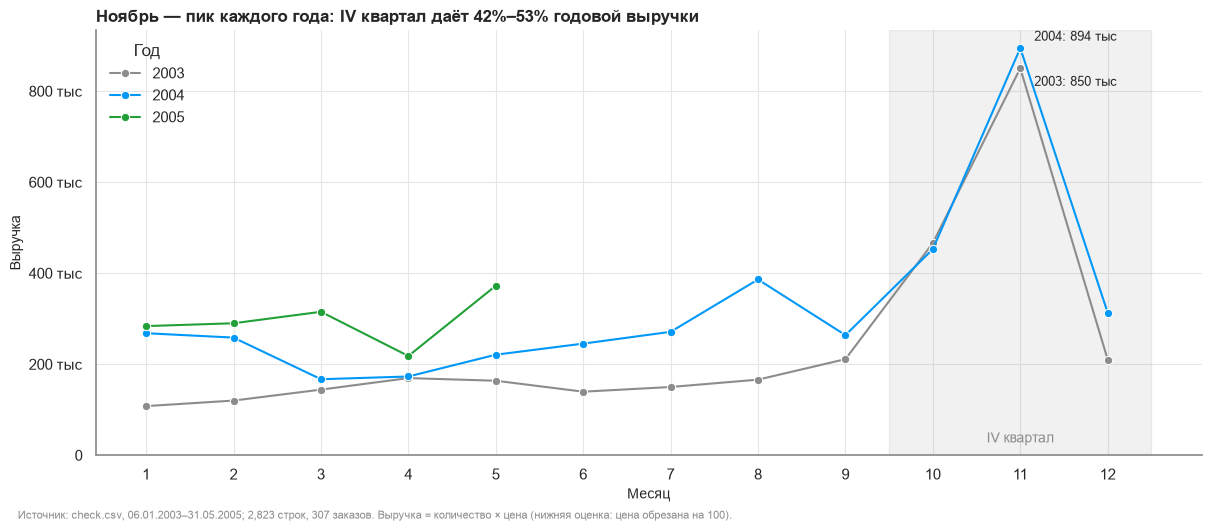

,доля IV квартала
YEAR_ID,
2003,52.7%
2004,42.4%


In [ ]:
def plot_monthly_by_year(ax, data):
    """Помесячная выручка: одна линия на год, месяцы на общей оси X — одинаковые месяцы легко сравнить."""
    monthly = data.groupby(["YEAR_ID", "MONTH_ID"], as_index=False)["SALES_EST"].sum()
    sns.lineplot(
        data=monthly, x="MONTH_ID", y="SALES_EST", hue="YEAR_ID",
        palette=[style.GRAY, style.BLUE, style.GREEN], marker="o", ax=ax
    )
    ax.axvspan(9.5, 12.5, color=style.GRAY, alpha=0.12)
    ax.text(
        11, 0.03, "IV квартал", ha="center", 
        color=style.GRAY, 
        transform=ax.get_xaxis_transform()
    )
    ax.set_xticks(range(1, 13))
    ax.set_xlabel("Месяц")
    ax.set_ylabel("Выручка")
    ax.set_ylim(0, None)
    set_money_axis(ax)
    ax.legend(title="Год")
    return monthly


# доля IV квартала — только по полным годам
by_qtr = df.query("YEAR_ID < 2005").pivot_table(
    index="YEAR_ID", columns="QTR_ID",
    values="SALES_EST", aggfunc="sum"
)
q4_share = by_qtr[4] / by_qtr.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 5), layout="constrained")
monthly = plot_monthly_by_year(ax, df)

nov = monthly.query("MONTH_ID == 11").sort_values("SALES_EST", ascending=False)
for offset, (_, row) in zip([8, -10], nov.iterrows()):
    ax.annotate(
        f"{row['YEAR_ID']:.0f}: {money_fmt(row['SALES_EST'])}", xy=(11, row["SALES_EST"]),
        xytext=(10, offset), textcoords="offset points", va="center", fontsize=9
    )

ax.set_title(
    f"Ноябрь — пик каждого года: IV квартал даёт "
    f"{q4_share.min():.0%}–{q4_share.max():.0%} годовой выручки", loc="left"
)
add_source(fig)
plt.show()
q4_share.map("{:.1%}".format).to_frame("доля IV квартала")

Ноябрьская выручка в 3–4 раза выше типичного месяца. Товар — коллекционные модели, покупатели — магазины подарков: логично, что они закупаются под рождественский сезон.
Для бизнеса это означает, что склад, логистика и кредитные лимиты клиентов должны быть готовы к октябрю–ноябрю.

### Находка 2. Рост — за счёт числа заказов

Сравниваем **одинаковый период** — январь–май каждого года. Выручку раскладываем на две компоненты:
`выручка = число заказов × средний заказ`. Три панели рядом, у каждой — своя величина и свои единицы.

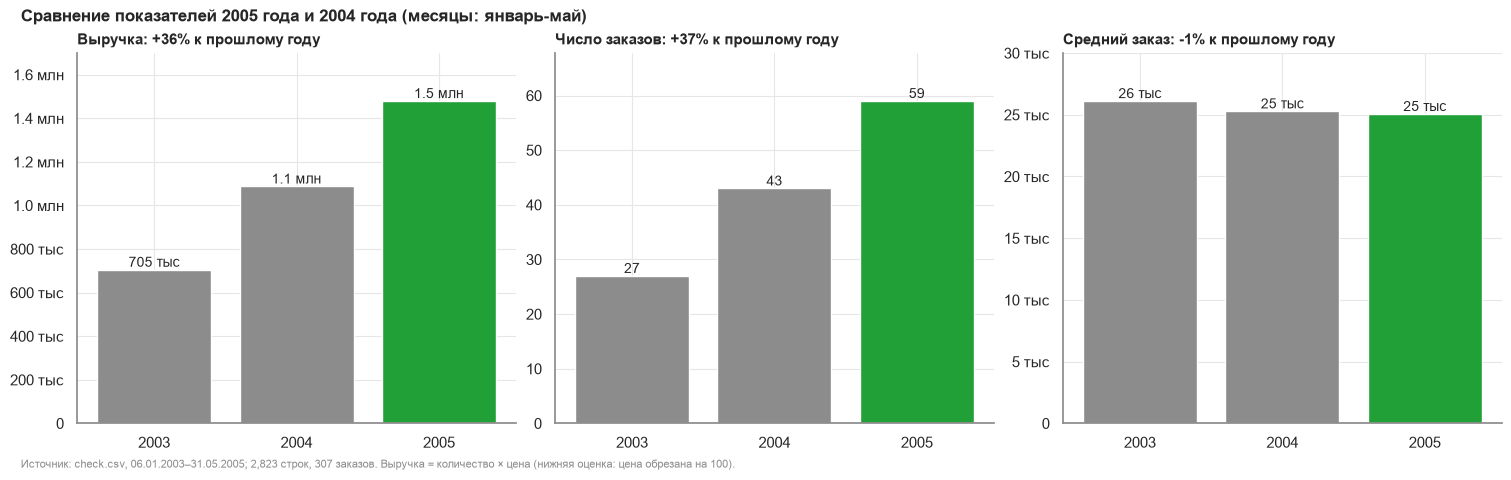

In [16]:
def plot_growth_decomposition(axes, orders_data, months=range(1, 6)):
    """Сравнение одинаковых месяцев по годам: выручка, число заказов, средний заказ."""
    same = orders_data[orders_data["ORDERDATE"].dt.month.isin(months)]
    by_year = same.groupby(same["ORDERDATE"].dt.year).agg(
        sales=("SALES_EST", "sum"), 
        n_orders=("SALES_EST", "size"),
        avg_order=("SALES_EST", "mean")
    )
    panels = [
        ("sales", "Выручка", money_fmt),
        ("n_orders", "Число заказов", lambda v: f"{v:.0f}"),
        ("avg_order", "Средний заказ", money_fmt)
    ]
    for ax, (col, title, fmt) in zip(axes, panels):
        values = by_year[col]
        ax.bar(
            values.index.astype(str), values.values,
            color=[style.GRAY] * (len(values) - 1) + [style.GREEN]
        )
        for x, v in enumerate(values.values):
            ax.text(x, v, fmt(v), ha="center", va="bottom", fontsize=10)
        change = values.iloc[-1] / values.iloc[-2] - 1
        ax.set_title(
            f"{title}: {change:+.0%} к прошлому году", 
            loc="left", fontsize=11
        )
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda v, p, f=fmt: f(v))
        )
        ax.margins(y=0.15)
    return by_year


fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), layout="constrained")
by_year = plot_growth_decomposition(axes, orders)
growth = by_year["sales"].iloc[-1] / by_year["sales"].iloc[-2] - 1
fig.suptitle(
    f"Сравнение показателей 2005 года и 2004 года (месяцы: январь-май)",
     x=0.01, ha="left", fontweight="bold"
)
add_source(fig)
plt.show()

Средний заказ за три года почти не меняется (~25 тыс.), а число заказов растёт. Значит, рост идёт **за счёт частоты или новых клиентов**, а не за счёт «более дорогой корзины».

### Находка 3. Classic Cars лидирует — и его вклад занижен

Две панели с **одинаковым порядком категорий**: слева — выручка, справа — доля строк с обрезанной ценой.

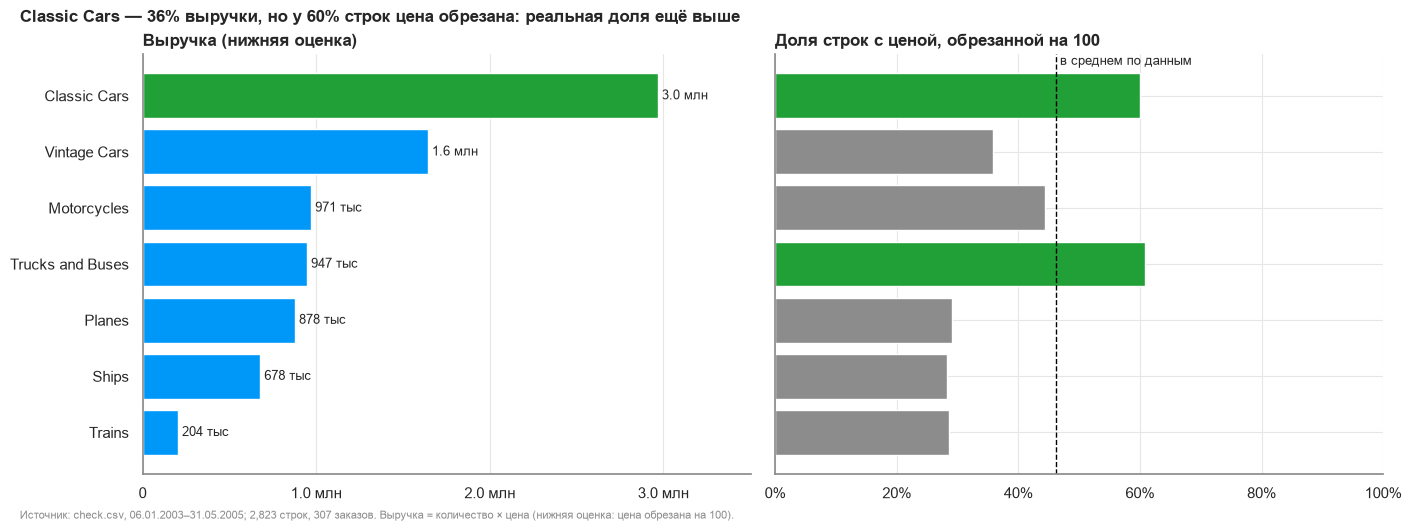

In [18]:
line_stats = df.groupby("PRODUCTLINE", observed=True).agg(
    sales=("SALES_EST", "sum"), 
    capped=("PRICE_CAPPED", "mean")
)
line_stats["share"] = line_stats["sales"] / line_stats["sales"].sum()
order = line_stats["sales"].sort_values().index
top = line_stats["sales"].idxmax()

fig, axes = plt.subplots(
    1, 2, figsize=(14, 5), 
    sharey=True, layout="constrained"
)
plot_barh(
    axes[0], line_stats["sales"], 
    title="Выручка (нижняя оценка)", 
    highlight=[top]
)
set_money_axis(axes[0], "x")

capped = line_stats.loc[order, "capped"]
axes[1].barh(
    capped.index.astype(str), capped.values,
    color=[style.GREEN if v > 0.5 else style.GRAY for v in capped.values]
)
axes[1].axvline(df["PRICE_CAPPED"].mean(), color=style.BLACK, ls="--", lw=1)
axes[1].text(df["PRICE_CAPPED"].mean(), len(capped) - 0.45, " в среднем по данным", fontsize=9)
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[1].set_xlim(0, 1)
axes[1].set_title("Доля строк с ценой, обрезанной на 100", loc="left")

fig.suptitle(
    f"{top} — {line_stats.loc[top, 'share']:.0%} выручки, но у "
    f"{line_stats.loc[top, 'capped']:.0%} строк цена обрезана: реальная доля ещё выше",
    x=0.01, ha="left", fontweight="bold"
)
add_source(fig)
plt.show()

Именно у лидеров (Classic Cars, Trucks and Buses) цена обрезана чаще всего. Значит, `SALES_EST` занижает их сильнее, чем у дешёвых линий (Trains, Ships).
**Рейтинг линий не изменится, а разрыв между лидером и остальными — вырастет.**

### Находка 4. Зависимость от ключевых клиентов

Используем **две панели**: топ клиентов и кривую концентрации на одной шкале в процентах.

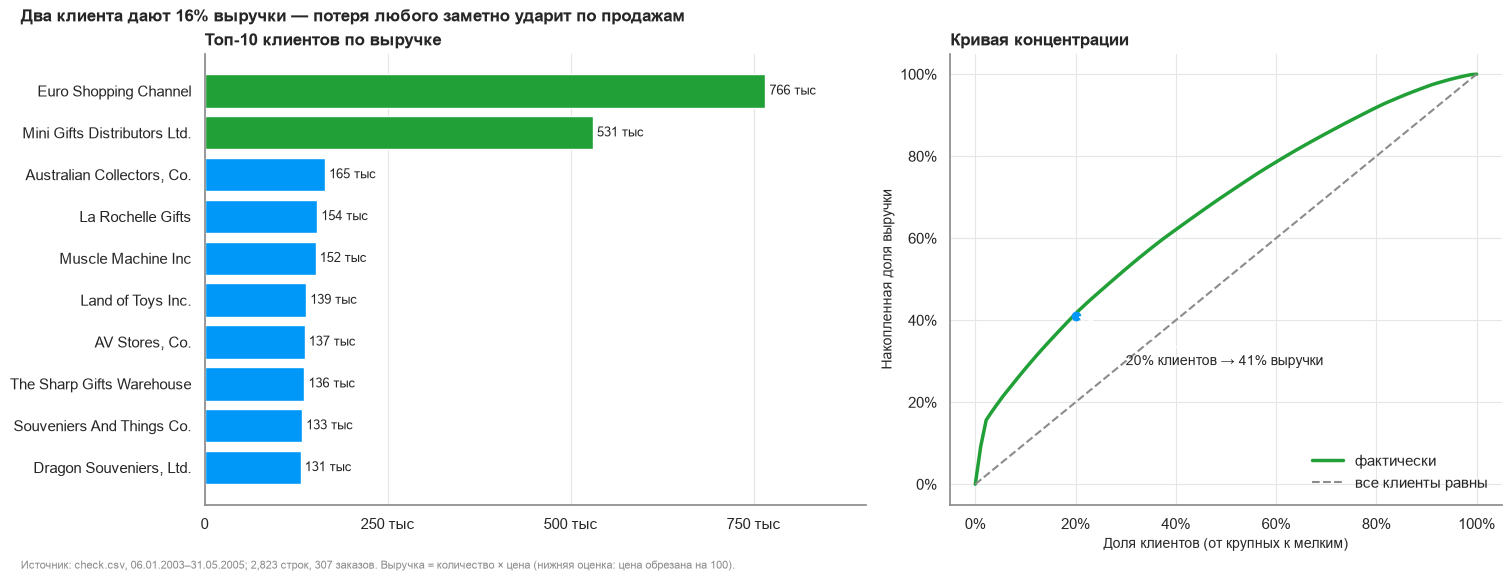

In [20]:
def concentration_curve(values: pd.Series) -> pd.DataFrame:
    """Доля клиентов (от крупных к мелким) против накопленной доли выручки."""
    v = values.sort_values(ascending=False).to_numpy()
    return pd.DataFrame({
        "customers_share": np.arange(0, len(v) + 1) / len(v),   # начинаем с точки (0, 0)
        "sales_share": np.r_[0, v.cumsum()] / v.sum()
    })


cust_sales = df.groupby("CUSTOMERNAME")["SALES_EST"].sum()
curve = concentration_curve(cust_sales)
top2_share = cust_sales.nlargest(2).sum() / cust_sales.sum()
top20pct = curve.loc[curve["customers_share"] <= 0.2, "sales_share"].iloc[-1]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), layout="constrained", width_ratios=[1.2, 1])
plot_barh(axes[0], cust_sales.nlargest(10), title="Топ-10 клиентов по выручке",
          highlight=cust_sales.nlargest(2).index)
set_money_axis(axes[0], "x")

axes[1].plot(
    curve["customers_share"], curve["sales_share"], 
    lw=2.5, color=style.GREEN, label="фактически"
)
axes[1].plot(
    [0, 1], [0, 1], ls="--", 
    color=style.GRAY, label="все клиенты равны"
)
axes[1].scatter([0.2], [top20pct], color=style.BLUE, zorder=3)
axes[1].annotate(
    f"20% клиентов → {top20pct:.0%} выручки", xy=(0.2, top20pct),
    xytext=(0.3, top20pct - 0.12), arrowprops={"arrowstyle": "->"}
)
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[1].set_xlabel("Доля клиентов (от крупных к мелким)")
axes[1].set_ylabel("Накопленная доля выручки")
axes[1].set_title("Кривая концентрации", loc="left")
axes[1].legend(loc="lower right")

fig.suptitle(
    f"Два клиента дают {top2_share:.0%} выручки — потеря любого заметно ударит по продажам",
    x=0.01, ha="left", fontweight="bold"
)
add_source(fig)
plt.show()

Два клиента заметно выделяются: Euro Shopping Channel и Mini Gifts Distributors.
Для них разумно иметь отдельные условия удержания и следить за их долей в выручке.

### Находка 5. Отменённые и приостановленные заказы — крупные

Каждая точка — **заказ**. Исполненные заказы показаны серым, чтобы выделить остальные цветом (цвет несёт смысл, а не украшает).

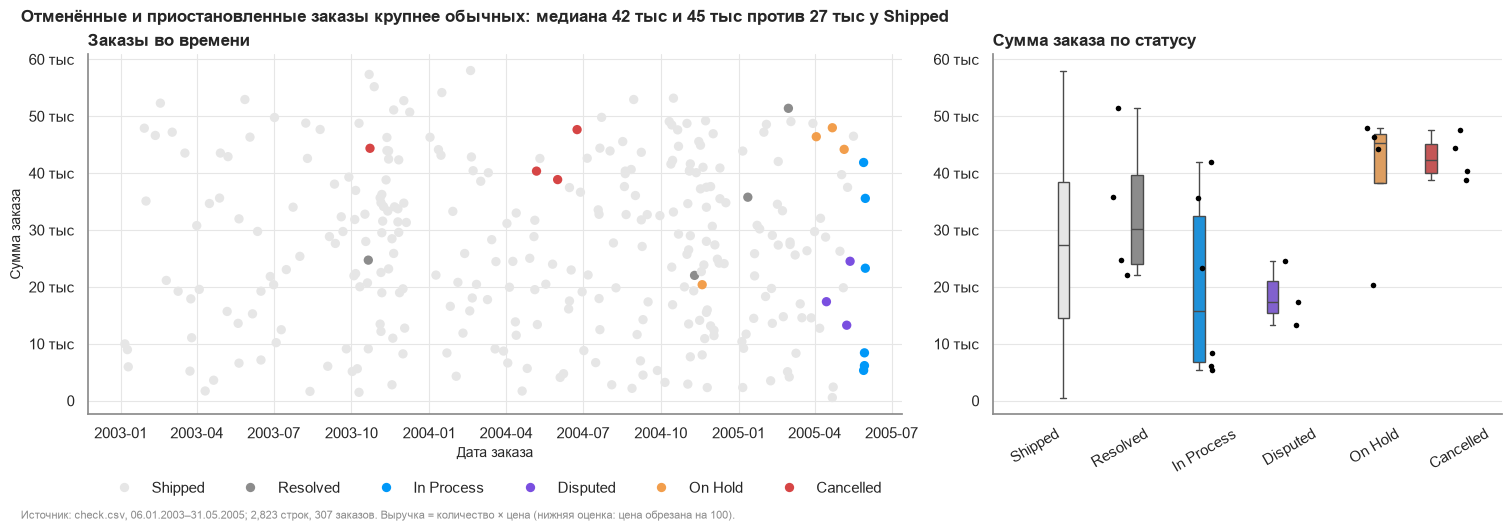

,orders,sales_median,max_qty_median
STATUS,,,
Shipped,286,27366.730,48.0
Resolved,4,30232.550,49.0
In Process,6,15846.465,52.5
Disputed,3,17400.000,65.0
On Hold,4,45278.645,68.0
Cancelled,4,42350.490,47.0


In [23]:
STATUS_ORDER = ["Shipped", "Resolved", "In Process", "Disputed", "On Hold", "Cancelled"]
PURPLE = style.CATEGORY_PALETTE[5]
ORANGE = style.CLUSTER_PALETTE[5]
STATUS_COLORS = dict(zip(
    STATUS_ORDER, 
    [style.GRAY_LIGHT, style.GRAY, style.BLUE, PURPLE, ORANGE, style.ERROR_RED]
))

fig, axes = plt.subplots(
    1, 2, figsize=(15, 5), 
    layout="constrained", width_ratios=[1.6, 1]
)


plot_order = orders.assign(
    _z=orders["STATUS"].isin(["Shipped", "Resolved"])
).sort_values("_z", ascending=False)
sns.scatterplot(
    data=plot_order, x="ORDERDATE", y="SALES_EST", 
    hue="STATUS", hue_order=STATUS_ORDER,
    palette=STATUS_COLORS, s=45, edgecolor="none", ax=axes[0]
)
axes[0].set_title("Заказы во времени", loc="left")
axes[0].set_xlabel("Дата заказа")
axes[0].set_ylabel("Сумма заказа")
set_money_axis(axes[0])
sns.move_legend(
    axes[0], "upper center", bbox_to_anchor=(0.5, -0.15), 
    ncols=6, title=None, frameon=False
)

sns.boxplot(
     data=orders, x="STATUS", y="SALES_EST", 
     order=STATUS_ORDER, hue="STATUS",
     palette=STATUS_COLORS, legend=False, showfliers=False, ax=axes[1]
)
sns.stripplot(
     data=orders.query("STATUS != 'Shipped'"), 
     x="STATUS", y="SALES_EST", order=STATUS_ORDER,
     color=style.BLACK, size=4, ax=axes[1]
)
axes[1].set_title("Сумма заказа по статусу", loc="left")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=30)
set_money_axis(axes[1])

med = orders.groupby("STATUS", observed=True)["SALES_EST"].median()
fig.suptitle(
     f"Отменённые и приостановленные заказы крупнее обычных: медиана "
     f"{money_fmt(med['Cancelled'])} и {money_fmt(med['On Hold'])} против {money_fmt(med['Shipped'])} у Shipped",
     x=0.01, ha="left", fontweight="bold"
)
add_source(fig)
plt.show()

orders.groupby("STATUS", observed=True).agg(
     orders=("SALES_EST", "size"), 
     sales_median=("SALES_EST", "median"),
     max_qty_median=("MAX_QTY", "median")
).reindex(STATUS_ORDER)

- `Cancelled` (4 заказа) и `On Hold` (4 заказа) — крупнее типичного `Shipped`; у `On Hold` ещё и самые большие количества в строке. Все строки-«выбросы» по количеству из ноутбука `01` — в заказах апреля–мая 2005, половина из них `On Hold`.
- `Disputed` и `In Process`, наоборот, мельче — значит, «проблемные статусы» нельзя сваливать в одну группу.
- Все заказы `In Process` — это **последние три дня выгрузки** (29–31 мая 2005): статус просто ещё не успел смениться. Это артефакт даты выгрузки, а не проблема процесса.

---
# Часть 3. Дашборд

Дашборд — это не «все графики на одном листе», а **главные метрики в неизменной форме**, которую читатель узнаёт с первого взгляда.
Функция принимает датафрейм, поэтому тот же дашборд можно построить для любого среза: `build_dashboard(df.query("YEAR_ID == 2004"))`.

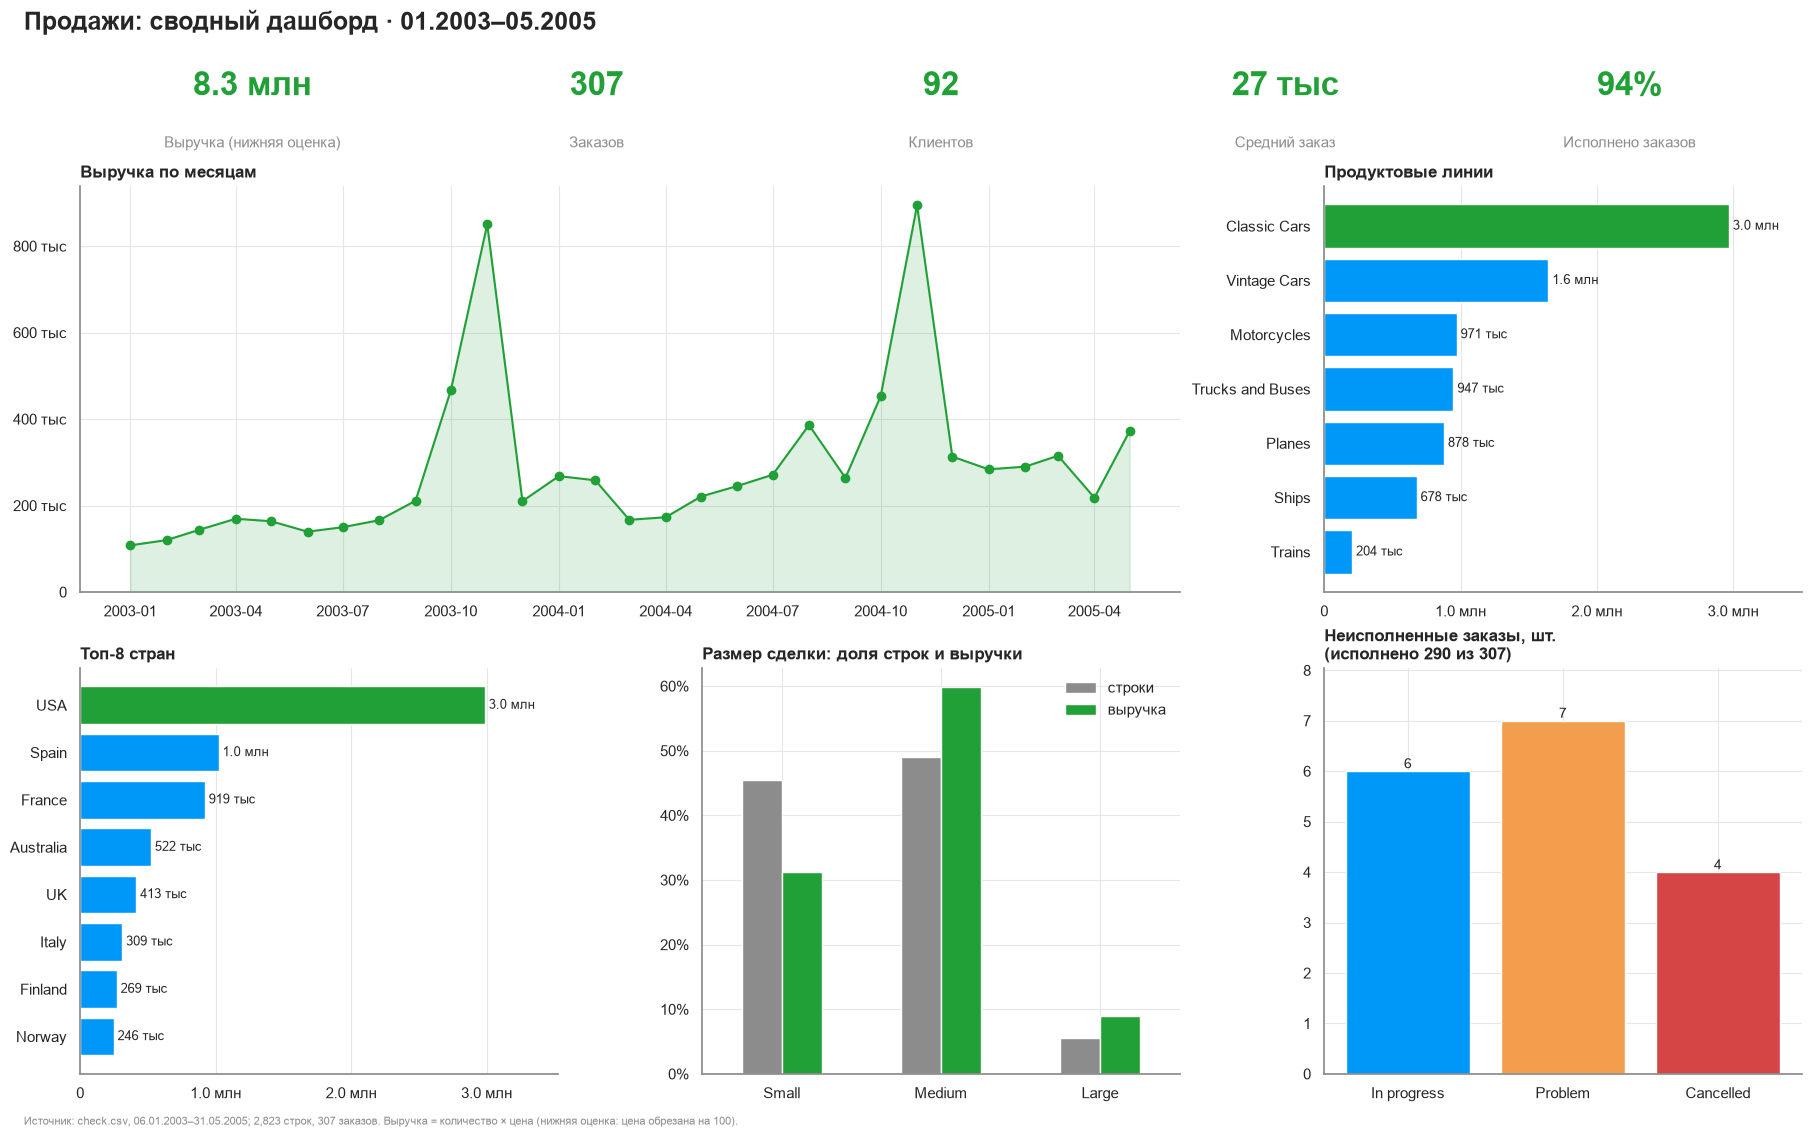

In [ ]:
def draw_kpis(ax, kpis: dict):
    """Строка крупных чисел-KPI."""
    ax.axis("off")
    for i, (label, value) in enumerate(kpis.items()):
        x = (i + 0.5) / len(kpis)
        ax.text(x, 0.62, value, ha="center", va="center", fontsize=24, fontweight="bold", color=style.GREEN)
        ax.text(x, 0.12, label, ha="center", va="center", fontsize=11, color=style.GRAY)


def build_dashboard(data: pd.DataFrame, title="Продажи: сводный дашборд"):
    ord_ = data.groupby("ORDERNUMBER").agg(
        SALES_EST=("SALES_EST", "sum"),
        STATUS_GROUP=("STATUS_GROUP", "first")
    )
    fig = plt.figure(figsize=(18, 11), layout="constrained")
    gs = fig.add_gridspec(3, 3, height_ratios=[0.28, 1, 1])

    draw_kpis(fig.add_subplot(gs[0, :]), {
        "Выручка (нижняя оценка)": money_fmt(data["SALES_EST"].sum()),
        "Заказов": f"{len(ord_)}",
        "Клиентов": f"{data['CUSTOMERNAME'].nunique()}",
        "Средний заказ": money_fmt(ord_["SALES_EST"].mean()),
        "Исполнено заказов": f"{ord_['STATUS_GROUP'].eq('Completed').mean():.0%}",
    })

    # 1. Динамика: вся временная ось
    ax = fig.add_subplot(gs[1, :2])
    ts = data.groupby("YEAR_MONTH")["SALES_EST"].sum()
    ax.plot(ts.index, ts.values, marker="o", color=style.GREEN)
    ax.fill_between(ts.index, ts.values, color=style.GREEN, alpha=0.15)
    ax.set_title("Выручка по месяцам", loc="left")
    ax.set_ylim(0, None)
    set_money_axis(ax)

    # 2. Продуктовые линии
    ax = fig.add_subplot(gs[1, 2])
    lines = data.groupby("PRODUCTLINE", observed=True)["SALES_EST"].sum()
    plot_barh(ax, lines, title="Продуктовые линии", highlight=[lines.idxmax()])
    set_money_axis(ax, "x")

    # 3. Страны
    ax = fig.add_subplot(gs[2, 0])
    countries = data.groupby("COUNTRY", observed=True)["SALES_EST"].sum().nlargest(8)
    plot_barh(ax, countries, title="Топ-8 стран", highlight=[countries.idxmax()])
    set_money_axis(ax, "x")

    # 4. Размер сделки: доля в строках и в выручке
    ax = fig.add_subplot(gs[2, 1])
    deal = pd.DataFrame({
        "строки": data["DEALSIZE"].value_counts(normalize=True),
        "выручка": data.groupby("DEALSIZE", observed=True)["SALES_EST"].sum() / data["SALES_EST"].sum(),
    }).reindex(["Small", "Medium", "Large"])
    deal.plot.bar(ax=ax, rot=0, color=[style.GRAY, style.GREEN])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
    ax.set_title("Размер сделки: доля строк и выручки", loc="left")
    ax.set_xlabel("")

    # 5. Неисполненные заказы: исполненных в десятки раз больше, поэтому выносим их число в заголовок,
    #    а не рисуем столбик, который «задавит» остальные (или логарифм, у которого столбик не от нуля)
    ax = fig.add_subplot(gs[2, 2])
    group_colors = {"In progress": style.BLUE, "Problem": ORANGE, "Cancelled": style.ERROR_RED}
    status = ord_["STATUS_GROUP"].value_counts().reindex(group_colors.keys(), fill_value=0)
    ax.bar(status.index.astype(str), status.values, color=list(group_colors.values()))
    for x, v in enumerate(status.values):
        ax.text(x, v, f"{v}", ha="center", va="bottom")
    n_done = ord_["STATUS_GROUP"].eq("Completed").sum()
    ax.set_title(f"Неисполненные заказы, шт.\n(исполнено {n_done} из {len(ord_)})", loc="left")
    ax.margins(y=0.15)

    period = f"{data['ORDERDATE'].min():%m.%Y}–{data['ORDERDATE'].max():%m.%Y}"
    fig.suptitle(f"{title} · {period}", fontsize=18, fontweight="bold", x=0.01, ha="left")
    add_source(fig)
    return fig


fig = build_dashboard(df)
fig.savefig(REPORT_DIR / "dashboard_matplotlib.png", dpi=150, bbox_inches="tight")
plt.show()

Обратите внимание на детали дашборда:

- **KPI сверху** — читатель получает ответ на первом экране;
- исполненных заказов в десятки раз больше остальных, поэтому их число вынесено в заголовок панели, а на столбиках — только неисполненные: так мелкие категории видны, а ось Y начинается с нуля (логарифмическая шкала у столбиков ломает принцип «длина = величина»);
- панель «размер сделки» показывает, что `Large` — 6% строк, но 9% выручки, а `Medium` — основа бизнеса;

---
# Часть 4. Гипотезы

Графики не доказывают причины — они подсказывают, **что проверять дальше**. Для каждой гипотезы: что видим, как проверить, какое решение от этого зависит.

| # | Гипотеза | Что видим |
|---|---|---|
| **H1** | **Сезонность спроса: клиенты закупаются под Рождество.** IV квартал будет пиком и в 2005 году | ноябрь — максимум в 2003 и 2004; Q4 = 42–53% года |
| **H2** | **Рост идёт за счёт числа заказов, а не их размера** | янв–май: заказы +37%, средний заказ ≈ стабилен |
| **H3** | **Выручка дорогих линий занижена сильнее, разрыв лидера больше** | у Classic Cars и Trucks 60% цен обрезаны на 100 |
| **H4** | **Крупные заказы чаще попадают в `On Hold` и отменяются** (например, из-за кредитного лимита клиента) | медиана `On Hold`/`Cancelled` ~42–45 тыс. против ~27 тыс.; половина строк > 67 шт. — `On Hold` |

Покажем, как сделать **первый шаг проверки H4**: сравним суммы заказов непараметрическим тестом Манна–Уитни (у сумм тяжёлый хвост, поэтому сравниваем не средние, а ранги).

In [25]:
risky = orders.loc[orders["STATUS"].isin(["On Hold", "Cancelled"]), "SALES_EST"]
completed = orders.loc[orders["STATUS_GROUP"].eq("Completed"), "SALES_EST"]

test = stats.mannwhitneyu(risky, completed, alternative="greater")
print(f"On Hold + Cancelled: n = {len(risky)}, медиана = {risky.median():,.0f}")
print(f"Исполненные:         n = {len(completed)}, медиана = {completed.median():,.0f}")
print(f"Манна–Уитни (альтернатива: On Hold/Cancelled крупнее): p-value = {test.pvalue:.4f}")

On Hold + Cancelled: n = 8, медиана = 44,261
Исполненные:         n = 290, медиана = 27,367
Манна–Уитни (альтернатива: On Hold/Cancelled крупнее): p-value = 0.0023


p-value маленький, но есть две оговорки:

1. таких заказов всего 8 — выборка очень маленькая;
2. гипотезу мы **придумали, глядя на эти же данные**, а потом проверили на них же — такой p-value получается слишком оптимистичным.

Честный вывод: **данные согласуются с H4, но не доказывают её.** Проверять нужно на новых данных (заказы после мая 2005).

---

**Отчёт без кода** можно собрать командой:
```bash
jupyter nbconvert --to html --no-input --execute 02_matplotlib_seaborn_report.ipynb
```